In [ ]:
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

# Normal points
X, _ = make_blobs(
    n_samples=300,
    centers=1,
    cluster_std=1.0,
    random_state=42
)
# Anomalies
outliers = np.random.uniform(low=-8, high=8, size=(20, 2))
# Combine
data = np.vstack([X, outliers])

df = pd.DataFrame(data, columns=['Feature1', 'Feature2'])
print(df.head())

   Feature1   Feature2
0 -2.182270   8.795186
1 -1.761904   9.624656
2 -3.110904  10.866564
3 -2.395680   9.676417
4 -4.980842   8.217391


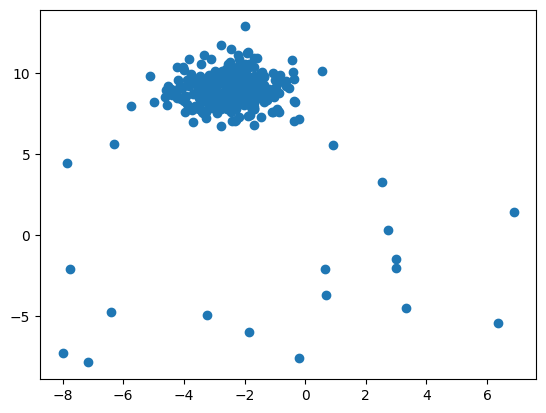

In [7]:
import matplotlib.pyplot as plt
plt.scatter(df.iloc[:,0],df.iloc[:,1])

In [8]:
from sklearn.ensemble import IsolationForest
clf=IsolationForest(contamination=0.2)
clf.fit(df)
predictions=clf.predict(df)

In [10]:
predictions

array([ 1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,
        1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1, -1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1

In [11]:
import numpy as np
abn_idx=np.where(predictions<0)
abn_idx

(array([  2,   4,  17,  27,  29,  44,  47,  54,  63,  66,  71,  73,  94,
        107, 120, 129, 130, 135, 145, 149, 155, 162, 174, 179, 193, 200,
        205, 209, 213, 214, 217, 233, 235, 243, 253, 257, 260, 264, 267,
        271, 277, 281, 282, 284, 293, 300, 301, 302, 303, 305, 306, 307,
        308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319]),)

In [12]:
x=df.values

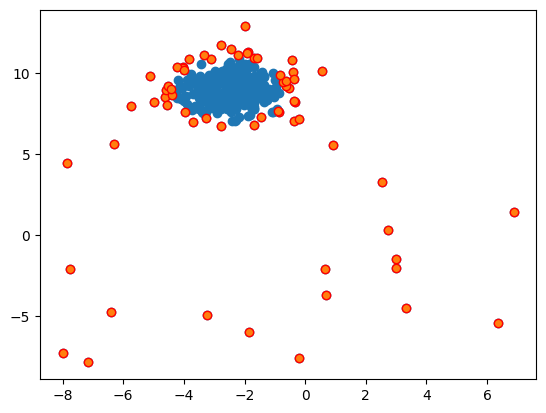

In [ ]:
plt.scatter(df.iloc[:,0],df.iloc[:,1])

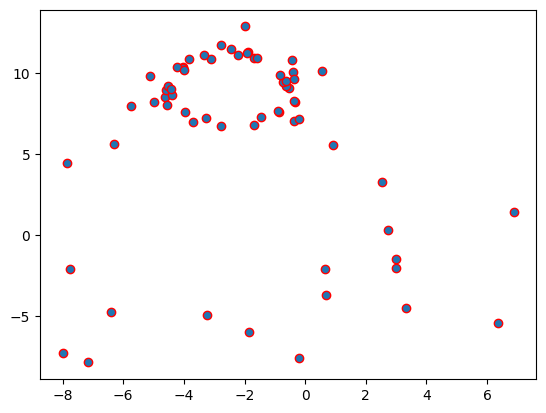

In [14]:
plt.scatter(x[abn_idx,0],x[abn_idx,1],edgecolors="r")

In [15]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

In [16]:
x,y=make_circles(n_samples=750,factor=0.3,noise=0.1)

In [17]:
x

array([[ 0.20845789, -1.19349693],
       [ 0.55841895, -0.82906563],
       [-0.56495046, -0.95266433],
       ...,
       [-0.91183796,  0.55793224],
       [ 0.40917829, -0.00192982],
       [-0.9398783 , -0.11908939]], shape=(750, 2))

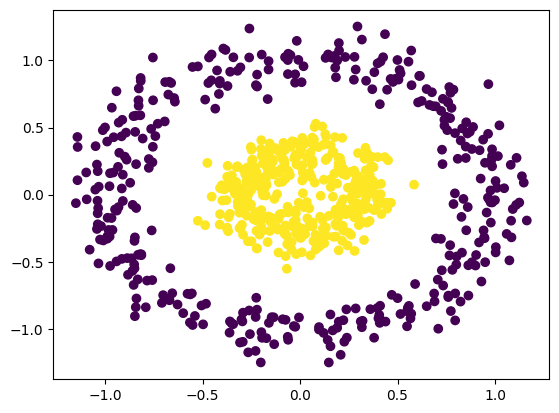

In [18]:
plt.scatter(x[:,0],x[:,1],c=y)

In [19]:
dbscan=DBSCAN(eps=0.10)

In [20]:
dbscan.fit_predict(x)

array([ 0,  0,  1,  4,  0,  2,  3,  4, -1, 13,  4, 10,  8,  4,  4,  4,  4,
        5, -1,  4, -1,  6,  7, -1,  4,  8,  4,  8,  5,  4, -1,  5,  4,  8,
        5, -1,  4,  9,  2,  4,  5, -1,  4,  4, -1,  6,  4,  9,  4,  6,  5,
       11, -1,  7,  4,  6, 10,  7,  9,  4,  7,  4,  4,  5, 11,  4,  2,  6,
        4,  4, 11,  0,  4,  4,  4, -1,  2,  4,  4, -1, -1,  4,  4,  9,  4,
        4,  2,  9,  7,  4,  4,  0,  5,  4,  2, 13,  2,  2,  4,  5,  4,  4,
        4,  4,  4,  4, 12,  0,  7,  1,  4, -1, -1, -1,  3,  7,  4,  4,  4,
        4,  0,  8,  4,  7,  5,  2, -1,  4,  7,  4,  4,  4,  4,  4,  7,  2,
        8,  4,  2, 11,  4,  4,  4,  4,  7,  4,  4,  3,  4,  7,  4, 14,  4,
        4,  4,  8, 11,  4,  5, 13,  3,  7,  7,  2,  4,  2,  4, -1,  9,  4,
        4,  4,  0,  0,  6,  8,  4,  0,  4,  4, -1,  0,  4,  4,  4,  4, 11,
       12,  4,  4,  0,  4,  4,  0,  4,  4, 13, 12,  2,  4,  4,  4,  4,  8,
       -1,  6,  0,  8,  9,  6,  4,  4,  4,  4,  6,  2,  2,  4,  5,  4, 14,
       12, -1,  4,  5,  4

In [21]:
dbscan.labels_

array([ 0,  0,  1,  4,  0,  2,  3,  4, -1, 13,  4, 10,  8,  4,  4,  4,  4,
        5, -1,  4, -1,  6,  7, -1,  4,  8,  4,  8,  5,  4, -1,  5,  4,  8,
        5, -1,  4,  9,  2,  4,  5, -1,  4,  4, -1,  6,  4,  9,  4,  6,  5,
       11, -1,  7,  4,  6, 10,  7,  9,  4,  7,  4,  4,  5, 11,  4,  2,  6,
        4,  4, 11,  0,  4,  4,  4, -1,  2,  4,  4, -1, -1,  4,  4,  9,  4,
        4,  2,  9,  7,  4,  4,  0,  5,  4,  2, 13,  2,  2,  4,  5,  4,  4,
        4,  4,  4,  4, 12,  0,  7,  1,  4, -1, -1, -1,  3,  7,  4,  4,  4,
        4,  0,  8,  4,  7,  5,  2, -1,  4,  7,  4,  4,  4,  4,  4,  7,  2,
        8,  4,  2, 11,  4,  4,  4,  4,  7,  4,  4,  3,  4,  7,  4, 14,  4,
        4,  4,  8, 11,  4,  5, 13,  3,  7,  7,  2,  4,  2,  4, -1,  9,  4,
        4,  4,  0,  0,  6,  8,  4,  0,  4,  4, -1,  0,  4,  4,  4,  4, 11,
       12,  4,  4,  0,  4,  4,  0,  4,  4, 13, 12,  2,  4,  4,  4,  4,  8,
       -1,  6,  0,  8,  9,  6,  4,  4,  4,  4,  6,  2,  2,  4,  5,  4, 14,
       12, -1,  4,  5,  4

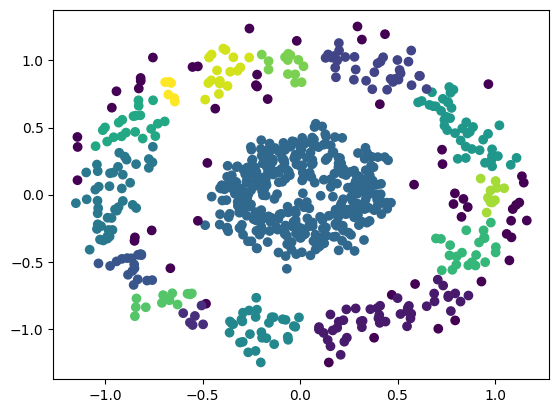

In [24]:
plt.scatter(x[:,0],x[:,1],c=dbscan.labels_)